# Random Forest — Strategy A: SMOTE Oversampling

A Random Forest classifier is trained using SMOTE oversampling to increase the representation of the minority diabetes class in the training data. SMOTE is applied inside the cross-validation pipeline to avoid leakage. Hyperparameter tuning is performed to optimize the number of trees, tree depth, split criteria, and leaf size, aiming to improve model discrimination while reducing overfitting.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [3]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pipeline_rf_a = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        max_depth=None,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

scores = cross_val_score(
    pipeline_rf_a, X_train_final, y_train,
    cv=cv, scoring="roc_auc", n_jobs=-1
)
print(f"RF A — CV ROC AUC: {scores.mean():.4f} ± {scores.std():.4f}")

RF A — CV ROC AUC: 0.8153 ± 0.0103


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

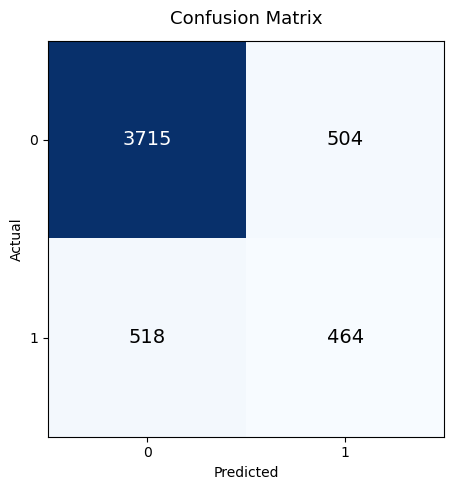

In [4]:
pipeline_rf_a.fit(X_train_final, y_train)

y_pred = pipeline_rf_a.predict(X_test_final)
y_pred_proba = pipeline_rf_a.predict_proba(X_test_final)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix", color="black", fontsize=13, pad=12)
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

for text in disp.text_.ravel():
    text.set_color("black")
    text.set_fontsize(14)
disp.text_[0, 0].set_color("white")

plt.tight_layout()
plt.show()

In [5]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8035
ROC AUC: 0.8090
Confusion Matrix:
[[3715  504]
 [ 518  464]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      4219
         1.0       0.48      0.47      0.48       982

    accuracy                           0.80      5201
   macro avg       0.68      0.68      0.68      5201
weighted avg       0.80      0.80      0.80      5201



## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [6]:
metrics = {

    "Strategy": "SMOTE",

    "Model": "Random Forest",

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_pred_proba)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/random_forest_oversampling_metrics.csv", index=False)

# SHAP

In [ ]:
import shap
import numpy as np

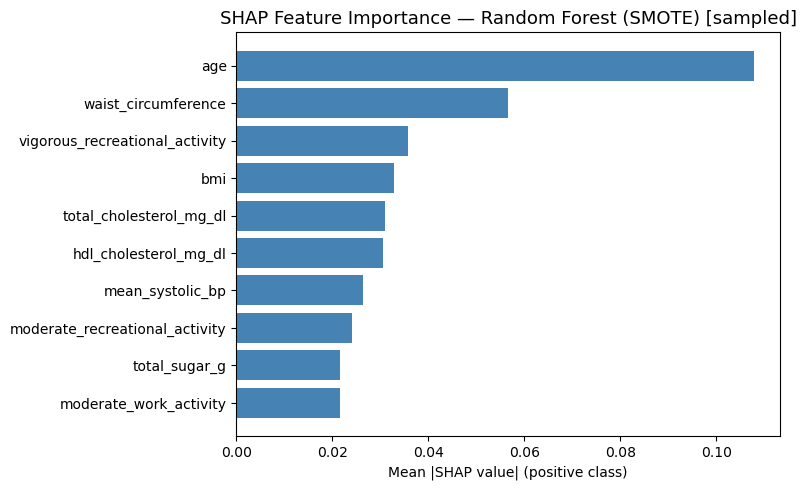

 rank                        feature  importance
    1                            age    0.107864
    2            waist_circumference    0.056693
    3 vigorous_recreational_activity    0.035751
    4                            bmi    0.032821
    5        total_cholesterol_mg_dl    0.031011
    6          hdl_cholesterol_mg_dl    0.030556
    7               mean_systolic_bp    0.026411
    8 moderate_recreational_activity    0.024184
    9                  total_sugar_g    0.021589
   10         moderate_work_activity    0.021553


In [8]:
rf_model = pipeline_rf_a.named_steps["model"]

# Subsample for speed — increase later for final results
X_sample = X_test_final.sample(n=200, random_state=42)

shap_values = shap.TreeExplainer(rf_model).shap_values(X_sample, check_additivity=False)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

shap_df = (
    pd.DataFrame({"feature": X_sample.columns, "importance": np.abs(shap_vals).mean(axis=0)})
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
shap_df["rank"] = shap_df.index + 1

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_df["feature"], shap_df["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_title("SHAP Feature Importance — Random Forest (SMOTE) [sampled]", fontsize=13)
ax.set_xlabel("Mean |SHAP value| (positive class)")
plt.tight_layout()
plt.show()

print(shap_df[["rank", "feature", "importance"]].to_string(index=False))

# Permutation

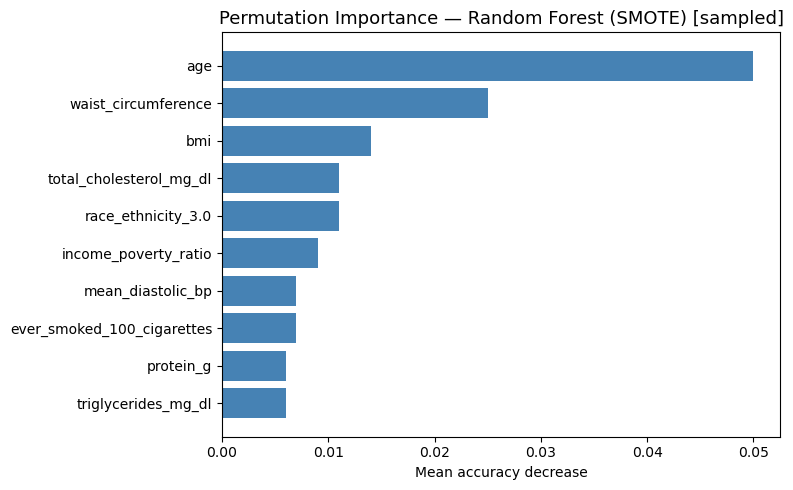

 rank                    feature  importance
    1                        age       0.050
    2        waist_circumference       0.025
    3                        bmi       0.014
    4    total_cholesterol_mg_dl       0.011
    5         race_ethnicity_3.0       0.011
    6       income_poverty_ratio       0.009
    7          mean_diastolic_bp       0.007
    8 ever_smoked_100_cigarettes       0.007
    9                  protein_g       0.006
   10        triglycerides_mg_dl       0.006


In [12]:
from sklearn.inspection import permutation_importance

rf_model = pipeline_rf_a.named_steps["model"]

# n_repeats=5 keeps it fast for testing, raise to 10+ for final results
X_sample = X_test_final.sample(n=200, random_state=42)
y_sample = y_test.loc[X_sample.index]

result = permutation_importance(rf_model, X_sample, y_sample, n_repeats=5, random_state=42)

perm_df = (
    pd.DataFrame({"feature": X_test_final.columns, "importance": result.importances_mean})
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
perm_df["rank"] = perm_df.index + 1

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_title("Permutation Importance — Random Forest (SMOTE) [sampled]", fontsize=13)
ax.set_xlabel("Mean accuracy decrease")
plt.tight_layout()
plt.show()

print(perm_df[["rank", "feature", "importance"]].to_string(index=False))

# Built in Feature Importance

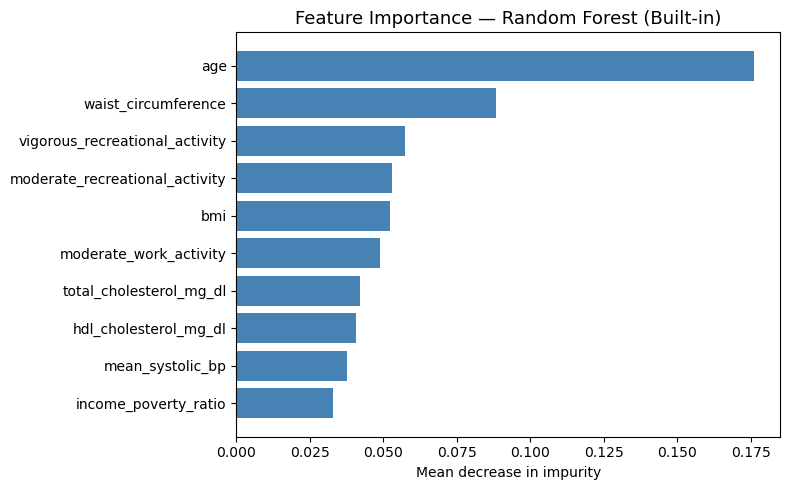

 rank                        feature  importance
    1                            age    0.176159
    2            waist_circumference    0.088222
    3 vigorous_recreational_activity    0.057307
    4 moderate_recreational_activity    0.052903
    5                            bmi    0.052367
    6         moderate_work_activity    0.048946
    7        total_cholesterol_mg_dl    0.041995
    8          hdl_cholesterol_mg_dl    0.040608
    9               mean_systolic_bp    0.037753
   10           income_poverty_ratio    0.032891


In [13]:
rf_model = pipeline_rf_a.named_steps["model"]

fi_df = (
    pd.DataFrame({"feature": X_test_final.columns, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
fi_df["rank"] = fi_df.index + 1

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df["feature"], fi_df["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Random Forest (Built-in)", fontsize=13)
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

print(fi_df[["rank", "feature", "importance"]].to_string(index=False))

# Writing to CSV file

In [ ]:
# 1. Add metadata to SHAP
shap_df["model"] = "Random Forest"
shap_df["strategy"] = "SMOTE"
shap_df["method"] = "SHAP"

# 2. Add metadata to Permutation
perm_df["model"] = "Random Forest"
perm_df["strategy"] = "SMOTE"
perm_df["method"] = "Permutation"

# 3. Add metadata to Built-in
fi_df["model"] = "Random Forest"
fi_df["strategy"] = "SMOTE"
fi_df["method"] = "Built-in"

# 4. Combine all three together
combined_df = pd.concat([shap_df, perm_df, fi_df], ignore_index=True)

# 5. Save the combined dataframe to CSV
combined_df[["model", "strategy", "method", "feature", "importance", "rank"]].to_csv(
    "../RESULTS/XAI/random_forest_A.csv", index=False
)